# Titanic Machine Learning for Disaster 

**Dataset:** Kaggle Titanic Competition Dataset

**Goal:** Predict if a passenger survived the sinking of the Titanic or not

**Source:** Kaggle Competition

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')


In [2]:
# Load the training data set.
train_data_raw = pd.read_csv('train.csv')

# Load the testing data set.
test_data_raw = pd.read_csv('test.csv')

In [3]:
# Load the training data set.
train_data = train_data_raw.copy()

# Load the testing data set.
test_data = test_data_raw.copy()

In [4]:
# Print a description of the training dataset.
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
# Print a description of the testing dataset.
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [6]:
# Print a statistical description of the testing dataset.
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# Print a statistical description of the testing dataset.
test_data.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [8]:
# Print the first few rows of the training data.
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
# Print the first few rows of the tgesting data.
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [10]:
# Check for missing values in the training dataset.
print(train_data.isna().sum().sort_values(ascending = False))

# Check for duplicate values in the training dataset.
print(train_data.duplicated().sum())

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64
0


In [11]:
# Check for missing values in the testing dataset.
print(test_data.isna().sum().sort_values(ascending = False))

# Check for duplicate values in the testing dataset.
print(test_data.duplicated().sum())

Cabin          327
Age             86
Fare             1
Name             0
Pclass           0
PassengerId      0
Sex              0
Parch            0
SibSp            0
Ticket           0
Embarked         0
dtype: int64
0


# Feature Engineering

In [12]:
def engineer_features(df):
    """Turn raw Titanic columns into modeling-ready features.

    - Title: extracted from Name, collapsed to Mr/Mrs/Miss/Master/Rare.
      Captures social status/age/gender signal without the noise of
      unique names.
    - FamilySize / IsAlone: derived from SibSp + Parch.
    - Deck: first letter of Cabin, 'U' for unknown (Cabin is ~77-78%
      missing, so this is more honest than imputing a fake majority cabin).
    - Drops Name, Ticket, Cabin (raw, high-cardinality/leaky) and
      PassengerId (a row index with no predictive value).
    """
    df = df.copy()

    df['Title'] = df['Name'].str.extract(r',\s*([^\.]*)\.')
    df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss').replace('Mme', 'Mrs')
    common_titles = ['Mr', 'Mrs', 'Miss', 'Master']
    df['Title'] = df['Title'].where(df['Title'].isin(common_titles), 'Rare')

    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    df['Deck'] = df['Cabin'].str[0].fillna('U')

    df = df.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'])
    return df

In [13]:
# Keep PassengerId separately for the final submission file.
test_passenger_ids = test_data['PassengerId']

train_data = engineer_features(train_data)
test_data = engineer_features(test_data)

train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,Deck
0,0,3,male,22.0,1,0,7.2500,S,Mr,2,0,U
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2,0,C
2,1,3,female,26.0,0,0,7.9250,S,Miss,1,1,U
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0,C
4,0,3,male,35.0,0,0,8.0500,S,Mr,1,1,U


# EDA

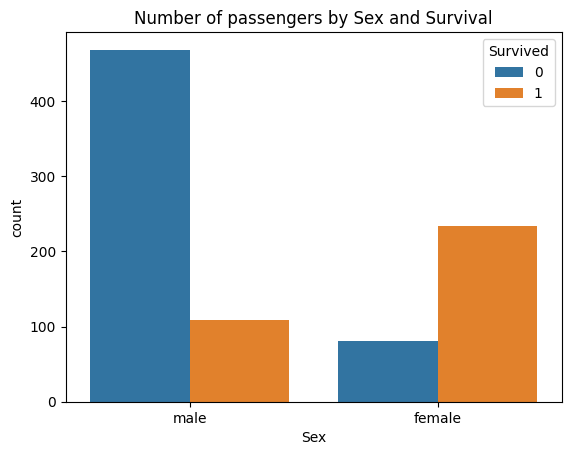

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [14]:
sns.countplot(data=train_data, x = 'Sex', hue = 'Survived')
plt.title('Number of passengers by Sex and Survival')
plt.show()

train_data.groupby('Sex')['Survived'].mean()

## Analysis: Survival by Sex

The sex-based survival distribution reveals a stark and historically significant disparity in Titanic survival rates. 

Among male passengers, approximately 450 individuals did not survive while only around 110 survived, reflecting a survival rate of roughly 20%. 

In contrast, female passengers experienced dramatically different outcomes, with approximately 230 surviving and only 80 perishing, translating to a survival rate near 75%.

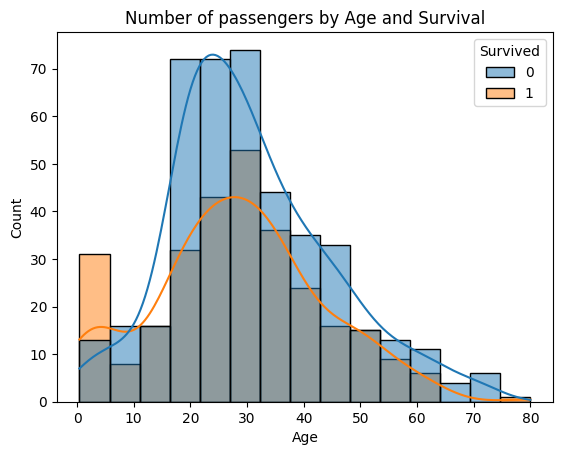

In [15]:
sns.histplot(data=train_data, x = 'Age', hue = 'Survived', bins=15, kde=True)
plt.title('Number of passengers by Age and Survival')
plt.show()

## Analysis: Survival by Age

The age distribution of survivors and non-survivors demonstrates a clear age-based survival pattern on the Titanic. The passenger population was heavily concentrated in the 20 to 50 age range, with a peak around 30 years old reaching approximately 200 passengers. 

Within this concentrated group, younger passengers, particularly children aged 0-15 years, show a substantially higher proportion of survivors relative to deaths, indicated by the higher orange shading in this age bracket.

Conversely, the middle-aged passenger group (20-50 years) displays predominantly blue coloring, indicating most did not survive. The elderly population (60+ years) represents a very small segment of passengers, and nearly all perished.

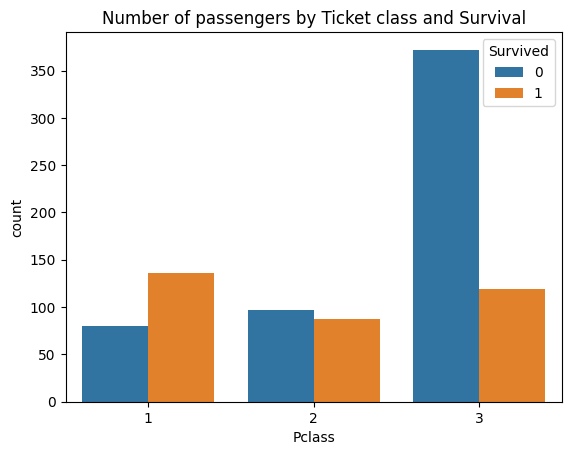

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [16]:
sns.countplot(data=train_data, x = 'Pclass', hue = 'Survived')
plt.title('Number of passengers by Ticket class and Survival')
plt.show()

train_data.groupby('Pclass')['Survived'].mean()

## Analysis: Survival by Ticket Class

The ticket class distribution reveals a strong socioeconomic correlation with survival outcomes on the Titanic. First-class passengers experienced a relatively balanced outcome, with approximately 140 survivors and 80 non-survivors, reflecting a survival rate of about 64%. 

Second-class passengers exhibited nearly equivalent results with roughly 90 survivors and 100 non-survivors, yielding a survival rate close to 47%.

In stark contrast, third-class passengers faced dramatically different odds: approximately 370 did not survive while only 120 survived, translating to a survival rate of merely 25%. This disparity of approximately 40 percentage points between first and third-class survival rates underscores the profound impact of wealth and social status during the disaster.

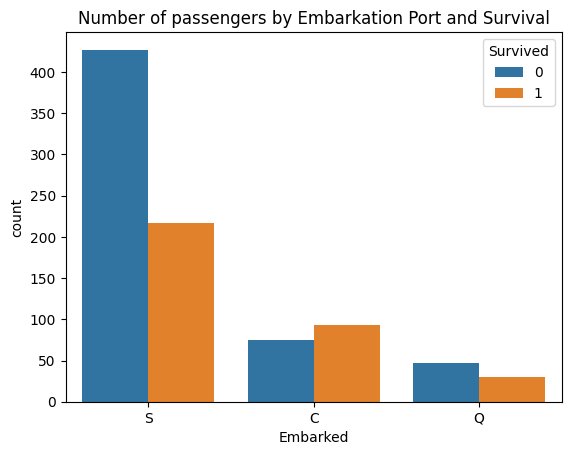

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [17]:
sns.countplot(data=train_data, x='Embarked', hue='Survived')
plt.title('Number of passengers by Embarkation Port and Survival')
plt.show()

train_data.groupby('Embarked')['Survived'].mean()

## Analysis: Survival by Embarkation Port

Passengers who boarded at Cherbourg (C) survived at a notably higher
rate (~55%) than those from Queenstown (Q, ~39%) or Southampton
(S, ~34%). This is very likely a proxy effect: Cherbourg had a higher
share of first-class passengers, rather than the port itself causing
the effect.

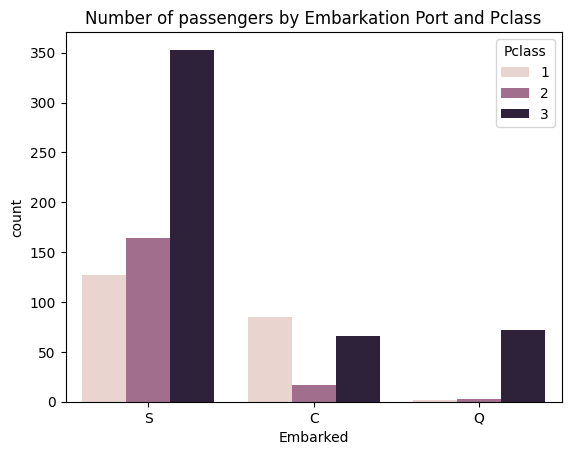

In [18]:
sns.countplot(data=train_data, x='Embarked', hue='Pclass')
plt.title('Number of passengers by Embarkation Port and Pclass')
plt.show()

## Analysis: Passengers by Embarkation Port and Class

Southampton (S) was by far the largest boarding point (~645 passengers) and was mostly 3rd class (~352), with 2nd (~164) and 1st (~127) making up the rest. 

Cherbourg (C) was much smaller (~168), but unusually skewed toward wealth: 1st class (~85) actually outnumbered 3rd class (~66) there, with very few 2nd-class passengers (~17). 

Queenstown (Q) was the smallest group (~77) and almost entirely 3rd class (~72). This class imbalance is the likely explanation for Cherbourg's higher survival rate (~55%). 

It isn't that the port itself mattered, but that Cherbourg boarded a much larger share of 1st-class passengers, who had better survival odds overall.

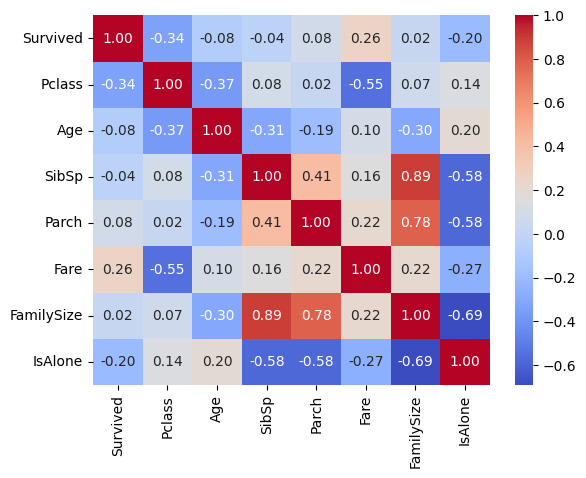

In [19]:
num_cols = train_data.select_dtypes(include = np.number)

sns.heatmap(data = num_cols.corr(), cmap = 'coolwarm', fmt = '.2f', annot = True)
plt.show()

## Analysis: Correlation Matrix Insights

The correlation heatmap reveals the complex relationships between variables in the Titanic dataset, with several key patterns emerging. 

The strongest predictor of survival is ticket class, showing a correlation of -0.34 with survival, negative because higher class numbers, third class passangers correspond to lower survival rates. 

Fare exhibits a moderate positive correlation of 0.26 with survival, indicating that passengers who paid higher fares were more likely to survive, which is inherently linked to ticket class differences. 

Age shows a weak negative correlation of -0.08 with survival, suggesting that younger passengers had slightly better odds. 

Interestingly, the number of siblings/spouses aboard has a weak negative correlation (-0.04) with survival, while the number of parents/children (Parch) shows a weak positive correlation (0.08), suggesting that traveling alone or with limited family may have been advantageous. 

The embarkation port demonstrates a moderate positive correlation of 0.26 with survival, possibly reflecting different passenger distributions across ports. 

Notably, Class and Fare show a strong negative correlation of -0.55, confirming the inverse relationship between ticket class and ticket price.

# Model

In [20]:
# Helper method to evaluate the models.
def evaluate_model(pipe, X_test, y_test, model_name):
    """Evaluate a fitted pipeline on a held-out set and report results.

    Computes accuracy and a full classification report, prints both,
    displays a confusion matrix, and returns the key metrics for the
    "Survived" class so results can be collected across multiple models.

    Args:
        pipe: A fitted sklearn Pipeline with a `.predict()` method.
        X_test: Feature matrix to evaluate on .
        y_test: True labels corresponding to X_test (0 = Died, 1 = Survived).
        model_name: Display name used as the confusion matrix title, e.g. 'Random Forest'.

    Returns:
        dict: {
            'accuracy': overall accuracy,
            'precision_survived': precision for the 'Survived' class,
            'recall_survived': recall for the 'Survived' class,
            'f1_survived': F1-score for the 'Survived' class
        }
    """

    y_pred = pipe.predict(X_test)

    test_accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred, target_names = ['Died', 'Survived'], output_dict = True)

    print(f'Test accuracy: {test_accuracy:.4f}')
    print(classification_report(y_test, y_pred, target_names = ['Died', 'Survived']))
    
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels = ['Died', 'Survived'], cmap = 'Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

    return {
        'accuracy': test_accuracy,
        'precision_survived': report['Survived']['precision'],
        'recall_survived': report['Survived']['recall'],
        'f1_survived': report['Survived']['f1-score']
    }

In [21]:
# Create a list of models.
models = {
    'RFC' : RandomForestClassifier,
    'KNN' : KNeighborsClassifier,
    'DTC' : DecisionTreeClassifier,
    'ADA': AdaBoostClassifier,
    'GB' : GradientBoostingClassifier
}

In [22]:
# Split the training dataset.
X = train_data.drop('Survived', axis = 1)
y = train_data['Survived']

In [23]:
# Split the testing dataset.
X_test = test_data

In [24]:
# Split the categorical and numerical columns.
cat_cols = X.select_dtypes(exclude = np.number).columns.tolist()
num_cols = X.select_dtypes(include = np.number).columns.tolist()

In [25]:
# Impute and scale numerical data.
numerical_pipeline = make_pipeline(
    SimpleImputer(strategy = 'mean'),
    StandardScaler()
)

# Impute and encode categorical data.
categorical_pipeline = make_pipeline(
    SimpleImputer(strategy = 'most_frequent'),
    OneHotEncoder(drop='first', handle_unknown = 'ignore')
)

preprocessor = ColumnTransformer(transformers = [
    ('categorical', categorical_pipeline, cat_cols),
    ('numerical', numerical_pipeline, num_cols)
])

In [26]:
# Split the training data into train and validation sets.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify = y,random_state=42)

Test accuracy: 0.7989
              precision    recall  f1-score   support

        Died       0.82      0.86      0.84       110
    Survived       0.76      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



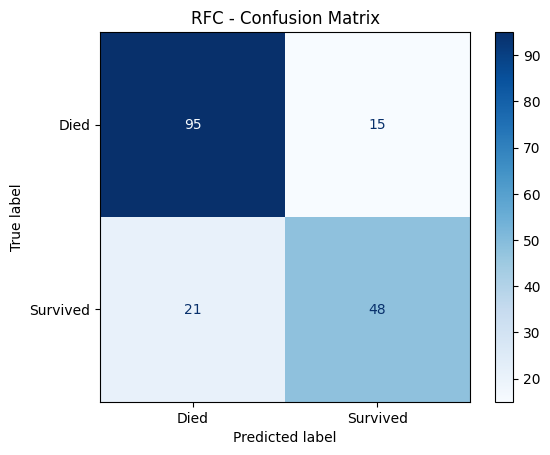

Test accuracy: 0.7989
              precision    recall  f1-score   support

        Died       0.82      0.86      0.84       110
    Survived       0.76      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



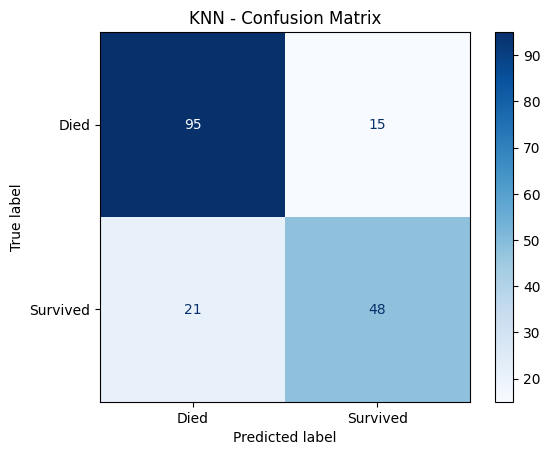

Test accuracy: 0.7765
              precision    recall  f1-score   support

        Died       0.81      0.84      0.82       110
    Survived       0.72      0.68      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.77      0.78      0.78       179



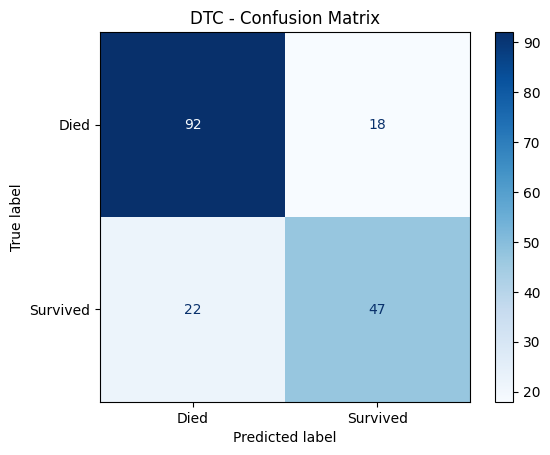

Test accuracy: 0.8045
              precision    recall  f1-score   support

        Died       0.86      0.82      0.84       110
    Survived       0.73      0.78      0.76        69

    accuracy                           0.80       179
   macro avg       0.79      0.80      0.80       179
weighted avg       0.81      0.80      0.81       179



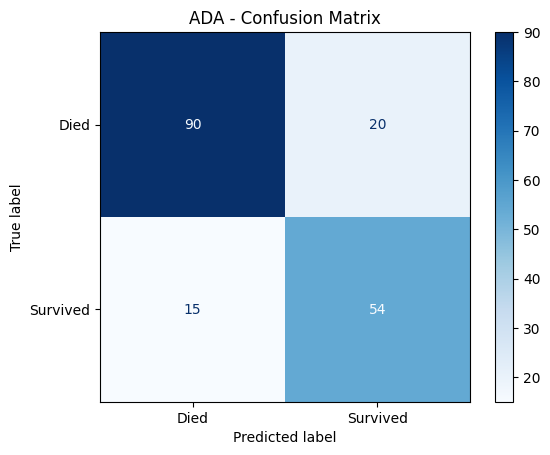

Test accuracy: 0.7989
              precision    recall  f1-score   support

        Died       0.81      0.88      0.84       110
    Survived       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



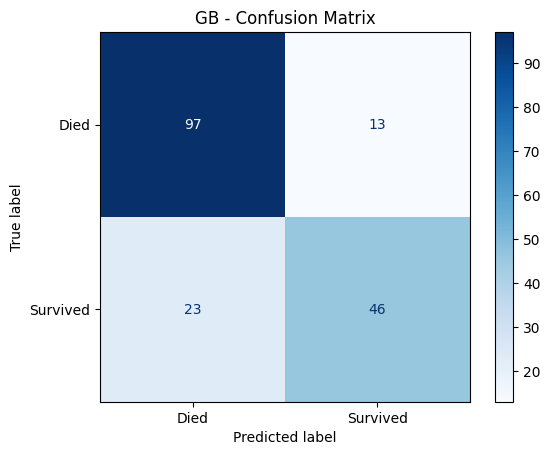

,accuracy,precision_survived,recall_survived,f1_survived
ADA,0.804469,0.729730,0.782609,0.755245
RFC,0.798883,0.761905,0.695652,0.727273
KNN,0.798883,0.761905,0.695652,0.727273
GB,0.798883,0.779661,0.666667,0.718750
DTC,0.776536,0.723077,0.681159,0.701493


In [27]:
# Evaluate the models.
model_results = []

for name, model in models.items():
    model_pipe = make_pipeline(preprocessor, model())
    model_pipe.fit(X_train, y_train)
    model_results.append(evaluate_model(model_pipe, X_val, y_val, name))
    
results_df = pd.DataFrame(model_results, index=models.keys()).sort_values('accuracy', ascending=False)
results_df

In [35]:
# Create the pipeline.
ada_pipe = make_pipeline(preprocessor, AdaBoostClassifier(estimator = DecisionTreeClassifier(random_state = 42), random_state=42))

# Perform future tuning
grid_params = {
    'adaboostclassifier__learning_rate': np.arange(0.01, 1.0, 0.05),
    'adaboostclassifier__n_estimators': np.arange(50, 500, 50),
    'adaboostclassifier__estimator__max_depth': np.arange(2, 6, 1)
}

# Create the grid.
grid = RandomizedSearchCV(estimator = ada_pipe, n_iter = 60,param_distributions = grid_params, cv = 5, random_state=42, n_jobs=-1)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'adaboostclassifier__estimator__max_depth': array([2, 3, 4, 5]), 'adaboostclassifier__learning_rate': array([0.01, ..., 0.91, 0.96]), 'adaboostclassifier__n_estimators': array([ 50, 1...50, 400, 450])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide `

In [36]:
print("Best params:", grid.best_params_)
print('Best CV accuracy:', round(grid.best_score_, 4))

Best params: {'adaboostclassifier__n_estimators': np.int64(250), 'adaboostclassifier__learning_rate': np.float64(0.26), 'adaboostclassifier__estimator__max_depth': np.int64(2)}
Best CV accuracy: 0.8301


Test accuracy: 0.7877
              precision    recall  f1-score   support

        Died       0.83      0.83      0.83       110
    Survived       0.72      0.72      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



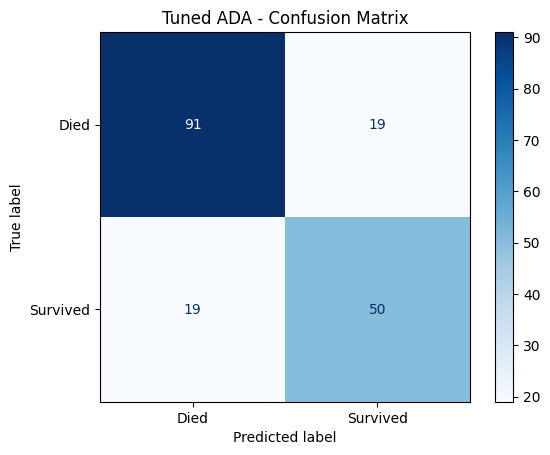

,accuracy,precision_survived,recall_survived,f1_survived
0,0.804469,0.729730,0.782609,0.755245
1,0.798883,0.761905,0.695652,0.727273
2,0.798883,0.761905,0.695652,0.727273
3,0.798883,0.779661,0.666667,0.718750
5,0.787709,0.724638,0.724638,0.724638
6,0.787709,0.724638,0.724638,0.724638
7,0.787709,0.724638,0.724638,0.724638
4,0.776536,0.723077,0.681159,0.701493


In [37]:
# Validate the tuned model on the held-out validation set before trusting it.
tuned_results = evaluate_model(grid.best_estimator_, X_val, y_val, 'Tuned ADA')
results_df = pd.concat([results_df, pd.DataFrame([tuned_results])], ignore_index=True)
results_df.sort_values('accuracy', ascending=False)

In [39]:
# Run the model with the tuned parameters.
final_gb = make_pipeline(preprocessor, AdaBoostClassifier(estimator = DecisionTreeClassifier(max_depth = 2, random_state = 42), n_estimators = 250, learning_rate = 0.26))
final_gb.fit(X_train, y_train)

# Predict the survival labels.
y_pred = final_gb.predict(X_test)

In [40]:
# Crate a data fame of the predicted labels.
output = pd.DataFrame({'PassengerId': test_passenger_ids, 'Survived': y_pred})
output

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


# Conclusions

## Key Findings from Exploratory Data Analysis

1. **Sex**: the strongest predictor of survival. Women survived at roughly 74%, men at roughly 19%, consistent with "women and children
   first."
2. **Ticket Class (Socioeconomic Status)**: survival fell from ~63% (1st class) to ~47% (2nd) to ~24% (3rd), about a 40-point gap between first and third class.
3. **Age**: younger passengers, especially children, had noticeably better survival odds than the 20-40 age band, which made up most of the ship and most of the deaths.
4. **Embarkation port**: Cherbourg passengers survived at a higher rate than Southampton or Queenstown passengers, most likely because Cherbourg had a higher proportion of first-class travelers, not because of the port itself.

## Correlation Analysis Insights

Among the numeric columns, `Pclass` has the strongest relationship with survival (-0.34), followed by `Fare` (0.26). `Age`, `SibSp`, and `Parch` are all weak on their own — which is why `FamilySize` and `IsAlone` were engineered from `SibSp`/`Parch` rather than relying on the raw columns directly.

## Model Selection and Performance

Five classifiers (Random Forest, KNN, Decision Tree, AdaBoost, and Gradient Boosting) were trained on a stratified 80/20 train/validation split using a shared preprocessing pipeline: mean imputation and scaling for numeric features, most-frequent imputation and one-hot encoding for categorical features, with all imputers/encoders fit only on the training fold. 

With default hyperparameters, the five models landed within a few points of each other on validation accuracy: AdaBoost led at 80.4%, Random Forest and KNN tied at 79.9%, Gradient Boosting followed close behind also at 79.9%, and the single Decision Tree trailed at 77.7%, with a survivor recall (68%) noticeably weaker than the ensemble methods. Given this narrow spread and AdaBoost's small edge, it was chosen for tuning: a `RandomizedSearchCV` over 60 parameter combinations and 5-fold cross-validation searched learning rate, number of estimators, and base-tree depth, landing on 250 estimators, a learning rate of 0.26, and stumps of depth 2, which raised cross-validated accuracy to 83.0%.

That gain didn't fully carry over to the held-out validation set, though, where the tuned model scored 78.8%, slightly below the untuned AdaBoost baseline, a gap most likely explained by the small validation size (179 passengers) making the accuracy estimate noisy, combined with some of the cross-validation improvement not generalizing cleanly to the one fixed split. 

The tuned model was nonetheless refit on the full training data and used to generate the final submission, since cross-validated performance is generally a more reliable estimate of generalization than a single validation split.
